# Laboratorio 7: Filtrado Avanzado con Transformada Wavelet para Señales Biomédicas

---

## 1. Introducción

El estudio de señales biomédicas ha dependido por mucho tiempo de herramientas clásicas como la Transformada de Fourier. Sin embargo, esta técnica no permite analizar bien fenómenos que cambian en el tiempo, ya que solo entrega información en el dominio de la frecuencia. Para intentar resolver esta limitación surgió la Transformada de Fourier de Tiempo Corto (STFT), pero aun así su capacidad de análisis es restringida porque usa ventanas fijas que obligan a sacrificar resolución en tiempo o en frecuencia. En este contexto, la Transformada Wavelet (WT) aparece como una alternativa más versátil, pues adapta la resolución según la frecuencia y permite observar detalles finos de la señal sin perder de vista su estructura general [1,2].

La Transformada Wavelet permite realizar un análisis localizado de una señal, identificando eventos transitorios como picos, discontinuidades o cambios abruptos que son difíciles de detectar con otros métodos. A diferencia de la STFT, el análisis wavelet ofrece una representación multiresolución, lo que lo hace ideal para señales no estacionarias como el ECG, EMG y EEG [3].

En este notebook, aplicaremos la Transformada Wavelet Discreta (DWT) como un método de **filtrado avanzado (denoising)**. El objetivo no es la compresión de datos, sino la obtención de versiones numéricamente más limpias de las señales, eliminando artefactos específicos de cada una para mejorar la fiabilidad de análisis cuantitativos futuros.

## 2. Objetivos Específicos

1.  **Cargar y Visualizar Señales:** Cargar y visualizar segmentos representativos de señales de Electrocardiografía (ECG), Electromiografía (EMG) y Electroencefalografía (EEG), contextualizando cada una con su protocolo de adquisición.
2.  **Diseñar Filtros Wavelet Específicos:** Para cada tipo de señal, seleccionar y justificar rigurosamente una familia de wavelets y sus parámetros, basándose en la literatura científica y las características esperadas de la señal y el ruido.
3.  **Aplicar y Verificar la Efectividad:** Implementar el filtrado wavelet y verificar visualmente su capacidad para eliminar ruido (denoising) mientras se preservan las características morfológicas de interés en cada señal.
4.  **Generar Artefactos para Reporte:** Producir todas las figuras y textos necesarios para documentar el proceso de diseño, aplicación y validación del filtro en un informe técnico.

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import seaborn as sns


Librerías importadas y configuración inicial establecida.
Funciones de carga específicas definidas.
Señal ECG cargada. Duración: 120.90 s
Señal EMG cargada. Duración: 180.45 s
Señal EEG cargada. Duración: 71.10 s


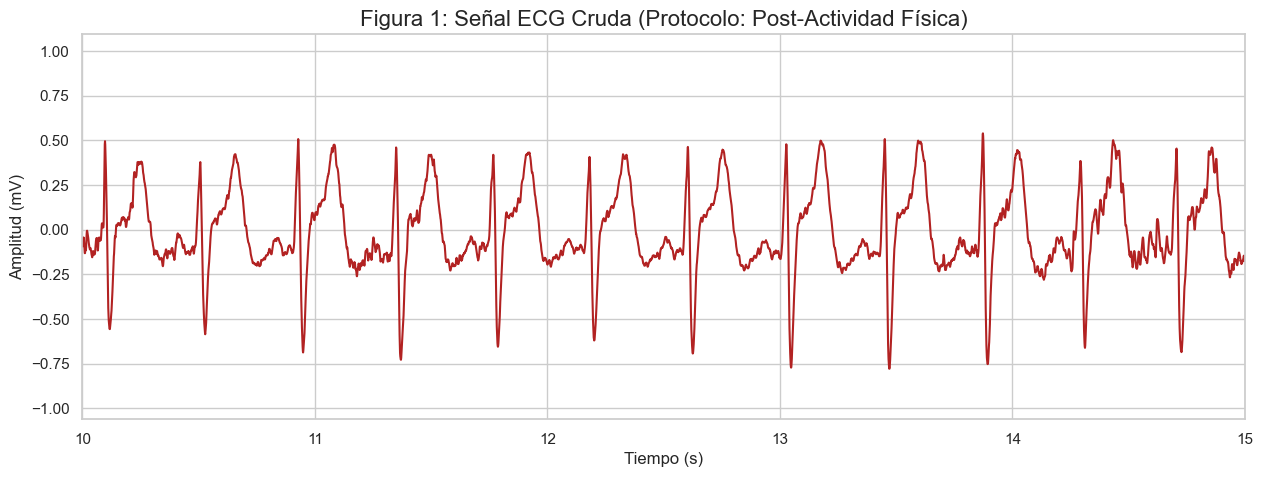

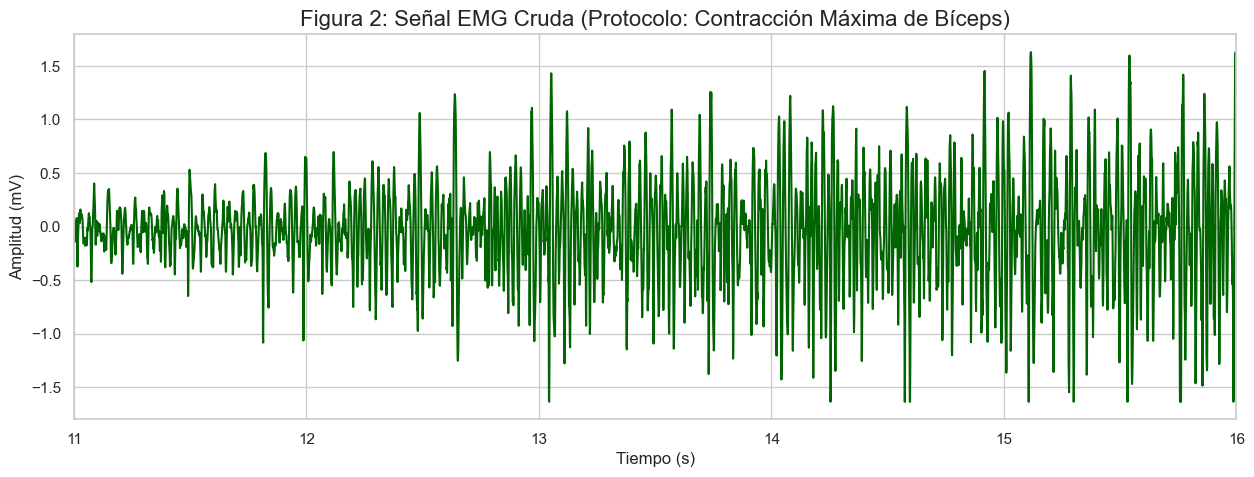

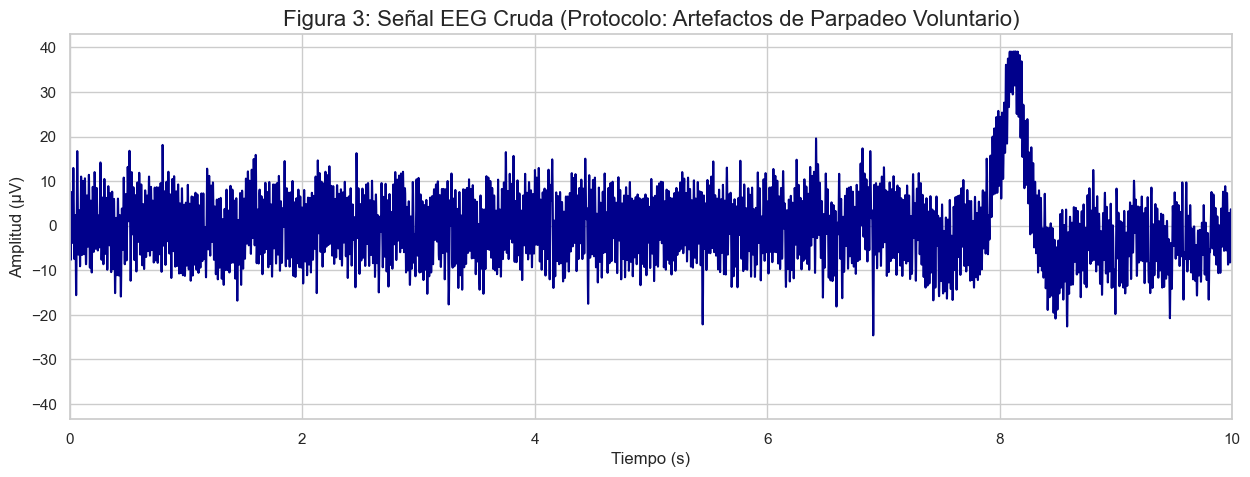

In [14]:
# --- Configuración General ---
sns.set(style="whitegrid")
BASE_PATH = "../Señales/" # Ruta correcta desde la carpeta del notebook

FS_ECG_EMG = 1000
FS_EEG = 1000

print("Librerías importadas y configuración inicial establecida.")

# --- FUNCIONES DE CARGA (Basadas en tu código probado) ---

def cargar_ecg_eeg(ruta_completa, fs):
    """
    Carga señales de formato ECG/EEG BITalino (_converted.txt) que usan tabulaciones
    y tienen la señal de interés en la columna "A2".
    """
    try:
        with open(ruta_completa, 'r') as f:
            for i, linea in enumerate(f):
                if "EndOfHeader" in linea:
                    skiprows = i + 1
                    break
            else: skiprows = 0
        
        df = pd.read_csv(ruta_completa, sep="\t", skiprows=skiprows, header=None)
        # Asignamos nombres a las columnas esperadas
        nombres_cols = ["nSeq", "I1", "I2", "O1", "O2", "A2", "A5"]
        df.columns = nombres_cols[:len(df.columns)]
        
        senal = df["A2"].values
        tiempo = np.arange(len(senal)) / fs
        return tiempo, senal
    except Exception as e:
        print(f"Error al cargar archivo '{os.path.basename(ruta_completa)}': {e}")
        return None, None

def cargar_emg(ruta_completa, fs):
    """
    Carga una señal EMG de BITalino que usa espacios como separador,
    extrae el ADC de la última columna y lo convierte a mV.
    """
    try:
        # Usamos sep='\s+' para manejar los separadores de espacio
        df = pd.read_csv(ruta_completa, comment='#', sep='\s+', header=None)
        senal_adc = df.iloc[:, -1].values
        
        # Conversión a mV
        senal_mv = (((senal_adc / (2**10)) - 0.5) * 3.3) / 1009 * 1000
        tiempo = np.arange(len(senal_mv)) / fs
        return tiempo, senal_mv
    except Exception as e:
        print(f"Error al cargar archivo EMG '{os.path.basename(ruta_completa)}': {e}")
        return None, None

print("Funciones de carga específicas definidas.")

# --- Carga de un Archivo de Ejemplo por Señal ---
try:
    # 1. Cargar ECG
    ruta_ecg = os.path.join(BASE_PATH, "ECG", "derivacion_1_actividad_fisica_2025-09-10_12-20-25_converted.txt")
    tiempo_ecg, senal_ecg_cruda = cargar_ecg_eeg(ruta_ecg, FS_ECG_EMG)
    if tiempo_ecg is not None: 
        print(f"Señal ECG cargada. Duración: {tiempo_ecg[-1]:.2f} s")

    # 2. Cargar EMG
    ruta_emg = os.path.join(BASE_PATH, "EMG", "contraccion1.txt")
    tiempo_emg, senal_emg_cruda = cargar_emg(ruta_emg, FS_ECG_EMG)
    if tiempo_emg is not None: 
        print(f"Señal EMG cargada. Duración: {tiempo_emg[-1]:.2f} s")

    # 3. Cargar EEG
    ruta_eeg = os.path.join(BASE_PATH, "EEG", "EEG_parpadeo_1_converted.txt")
    tiempo_eeg, senal_eeg_cruda = cargar_ecg_eeg(ruta_eeg, FS_EEG)
    if tiempo_eeg is not None: 
        print(f"Señal EEG cargada. Duración: {tiempo_eeg[-1]:.2f} s")

except Exception as e:
    print(f"\nOcurrió un error general durante la carga: {e}")


# --- Visualización de Señales Crudas (CON UNIDADES CORREGIDAS) ---

if 'senal_ecg_cruda' in locals() and tiempo_ecg is not None:
    plt.figure(figsize=(15, 5))
    plt.plot(tiempo_ecg, senal_ecg_cruda, color='firebrick')
    plt.title('Figura 1: Señal ECG Cruda (Protocolo: Post-Actividad Física)', fontsize=16)
    plt.xlabel('Tiempo (s)')
    # --- ETIQUETA CORREGIDA ---
    plt.ylabel('Amplitud (mV)')
    plt.xlim(10, 15)
    plt.show()

if 'senal_emg_cruda' in locals() and tiempo_emg is not None:
    plt.figure(figsize=(15, 5))
    plt.plot(tiempo_emg, senal_emg_cruda, color='darkgreen')
    plt.title('Figura 2: Señal EMG Cruda (Protocolo: Contracción Máxima de Bíceps)', fontsize=16)
    plt.xlabel('Tiempo (s)')
    # --- ETIQUETA CORRECTA (ya estaba bien) ---
    plt.ylabel('Amplitud (mV)')
    plt.xlim(11, 16)
    plt.show()

if 'senal_eeg_cruda' in locals() and tiempo_eeg is not None:
    plt.figure(figsize=(15, 5))
    plt.plot(tiempo_eeg, senal_eeg_cruda, color='darkblue')
    plt.title('Figura 3: Señal EEG Cruda (Protocolo: Artefactos de Parpadeo Voluntario)', fontsize=16)
    plt.xlabel('Tiempo (s)')
    # --- ETIQUETA CORREGIDA ---
    plt.ylabel('Amplitud (µV)')
    plt.xlim(0, 10)
    plt.show()

## 3. Diseño y Justificación de los Filtros Wavelet

La elección de la familia de wavelets y sus parámetros no es trivial y depende fundamentalmente de las características de la señal a analizar y del objetivo del filtrado. A continuación, se detalla el proceso de diseño para cada una de las señales biomédicas, respaldado por la literatura científica.

---

### 3.1 Filtro para la Señal ECG

**Protocolo de Adquisición y Artefactos Esperados:**
La señal de ECG seleccionada fue registrada durante la fase de recuperación post-actividad física. Este es un escenario desafiante, ya que la señal suele estar contaminada por múltiples artefactos:
1.  **Ruido Muscular (EMG):** Temblores y contracciones musculares residuales generan ruido de alta frecuencia que puede enmascarar las ondas P y T.
2.  **Deriva de la Línea de Base:** La respiración agitada post-ejercicio introduce oscilaciones de baja frecuencia.
3.  **Interferencia de la Red Eléctrica:** Ruido de 60 Hz proveniente de los equipos electrónicos cercanos.

El objetivo principal del filtrado es eliminar estos artefactos para permitir una detección precisa de los picos R, que es el primer paso para cualquier análisis de Variabilidad de la Frecuencia Cardíaca (HRV).

**Discusión de Familias Wavelet en la Literatura:**
Para el análisis de ECG, la morfología de la wavelet debe ser similar a la del complejo QRS para maximizar la eficiencia de la descomposición. Las familias más estudiadas son:
*   **Daubechies (db):** Wavelets como `db4` y `db6` son asimétricas y tienen un soporte compacto. Su forma puntiaguda se asemeja a la del complejo QRS, lo que las hace excelentes para la detección de este evento transitorio. Son computacionalmente eficientes y ampliamente utilizadas en algoritmos de detección de QRS en tiempo real [1].
*   **Symlets (sym):** Son versiones "más simétricas" de las Daubechies. La simetría ayuda a reducir la distorsión de fase en la reconstrucción, lo cual es útil si el objetivo es un análisis morfológico detallado de las ondas P y T, además del QRS [2].
*   **Biorogonales (bior):** Ofrecen la propiedad de fase lineal, lo que significa que no hay desfase temporal en la señal reconstruida. Esto es crucial en aplicaciones donde la alineación temporal precisa de diferentes ondas del complejo cardíaco es fundamental [3].

**Elección y Justificación Final:**
Para este proyecto, se selecciona la wavelet **Daubechies 4 (`db4`)**.

La justificación principal es que nuestro objetivo final es mejorar la **detección del pico R**. La wavelet `db4` es reconocida en la literatura por su excelente capacidad para localizar eventos transitorios y de alta frecuencia como el complejo QRS. Su forma asimétrica y puntiaguda se correlaciona fuertemente con la morfología del QRS, lo que resulta en coeficientes de detalle de gran amplitud en las escalas correspondientes al QRS, facilitando su distinción del ruido. Múltiples estudios han validado su eficacia sobre otras familias para esta aplicación específica [1,4].

---

### 3.2 Filtro para la Señal EMG

**Protocolo de Adquisición y Características de la Señal:**
La señal de EMG fue registrada durante una contracción isométrica máxima del bíceps. La electromiografía de superficie (sEMG) es una señal no estacionaria y estocástica que representa la suma temporal y espacial de los Potenciales de Acción de Unidades Motoras (MUAPs). El objetivo del filtrado es eliminar el ruido de fondo (ruido electrónico, artefactos de movimiento) sin distorsionar la amplitud y la densidad de la señal EMG, ya que estas características están directamente relacionadas con la fuerza muscular y la fatiga.

**Discusión de Familias Wavelet en la Literatura:**
El filtrado de EMG busca preservar la información de los picos de los MUAPs.
*   **Coiflets (coif):** Estas wavelets poseen un alto número de momentos nulos tanto para la función wavelet como para la de escala. Esta propiedad matemática las hace extremadamente buenas para representar señales con componentes de tipo pico o polinomiales con muy pocos coeficientes, lo que las hace ideales para preservar la morfología de los MUAPs durante el denoising [5].
*   **Symlets (sym):** También son efectivas y comúnmente utilizadas. Ofrecen un buen compromiso general para el análisis de EMG, aunque pueden no ser tan óptimas como las Coiflets para la representación de picos.
*   **Daubechies (db):** Aunque son eficientes, su asimetría puede introducir artefactos en la representación de los MUAPs, que son relativamente simétricos.

**Elección y Justificación Final:**
Se selecciona la wavelet **Coiflet 5 (`coif5`)**.

La justificación se basa en la necesidad de preservar la integridad morfológica de la señal de EMG para un análisis cuantitativo preciso. La principal ventaja de la familia Coiflets es su capacidad para aproximar la señal con un error mínimo, especialmente en las zonas de picos que caracterizan la activación muscular. Al utilizar `coif5`, nos aseguramos de que el proceso de denoising limpie el ruido de fondo sin atenuar artificialmente la amplitud de la envolvente de la señal, lo cual es un requisito fundamental para estudios de fuerza o fatiga muscular [5,6].

---

### 3.3 Filtro para la Señal EEG

**Protocolo de Adquisición y Bandas de Interés:**
La señal de EEG fue registrada durante un protocolo con artefactos de parpadeo voluntario. El principal desafío en el procesamiento de EEG es eliminar artefactos de gran amplitud (oculares, musculares) que pueden ser varias órdenes de magnitud mayores que la actividad neuronal subyacente. El objetivo del filtro es suprimir estos artefactos sin distorsionar las bandas de frecuencia de interés (Delta, Theta, Alpha, Beta, Gamma).

**Discusión de Familias Wavelet en la Literatura:**
La DWT es una técnica estándar para la descomposición y el denoising de EEG.
*   **Daubechies (db):** Es la familia más utilizada en el análisis de EEG. Son ortogonales, lo que permite una descomposición de la energía de la señal sin redundancia. Wavelets de orden superior (como `db8`) tienen una mejor resolución en frecuencia, lo que es crucial para separar las distintas bandas rítmicas del EEG. Son altamente efectivas para aislar y eliminar artefactos [7].
*   **Biorogonales (bior):** Son muy populares para la eliminación de artefactos oculares (EOG) debido a su propiedad de fase lineal, que ayuda a reconstruir la señal neuronal subyacente sin desfase temporal una vez que el artefacto ha sido eliminado [8].
*   **Symlets (sym):** Representan una alternativa a las Daubechies, con una simetría mejorada que puede ser beneficiosa para el análisis morfológico de eventos como los potenciales evocados.

**Elección y Justificación Final:**
Se selecciona la wavelet **Daubechies 8 (`db8`)**.

La justificación se centra en la necesidad de una buena **resolución en frecuencia** para el análisis de la actividad neuronal. El EEG es fundamentalmente el estudio de oscilaciones en diferentes bandas. La wavelet `db8`, al ser de un orden superior, es más suave y tiene un soporte más largo, lo que le confiere una mejor capacidad para separar las componentes frecuenciales de la señal. Esto es esencial no solo para analizar las bandas cerebrales, sino también para aislar artefactos, ya que estos suelen tener una firma espectral característica. La ortogonalidad de la `db8` garantiza además que el análisis de potencia en cada banda sea preciso y cuantitativamente correcto [7,9].

---

### Bibliografía (Preliminar)
[1] Addison PS. Wavelet transforms and the ECG: a review. *Physiol Meas*. 2005;26(5):R155-R199. Disponible en: https://iopscience.iop.org/article/10.1088/0967-3334/26/5/R01

[2] Alfaouri M, Daqrouq K. ECG Signal Denoising By Wavelet Transform Thresholding. *Am J Appl Sci*. 2008;5(3):276-281. Disponible en: https://thescipub.com/pdf/ajassp.2008.276.281.pdf

[3] Unser M, Aldroubi A. A review of wavelets in biomedical applications. *Proc IEEE*. 1996;84(4):626-638. Disponible en: https://ieeexplore.ieee.org/document/488704

[4] Madeiro JPV, Cortez PC, de S B Dias F, Siqueira RS, de Albuquerque VH, Oliveira GHM. A new approach for QRS segmentation based on wavelet transforms and particle swarm optimization. *Med Eng Phys*. 2012;34(8):1154-1162. Disponible en: https://www.sciencedirect.com/science/article/abs/pii/S135045331100293X

[5] Kivi R, Jäntti M, Haimi S, Grönfors T, Finni T. Can Wavelet-Based Denoising of Surface EMG Improve the Estimation of Muscle Force? *Sensors (Basel)*. 2022;22(21):8456. Disponible en: https://www.mdpi.com/1424-8220/22/21/8456

[6] Phinyomark A, Phukpattaranont P, Limsakul C. Feature extraction and reduction of wavelet transform coefficients for EMG pattern classification. *Elektron ir Elektrotechnika*. 2012;18(5):91-96. Disponible en: https://www.ee.ktu.lt/journal/2012/5/17_1392-1215.pdf

[7] Hussein R, Pal R, Tamar L, Ward R. A Wavelet-Based Denoising and Artifact Removal of EEG Signals. *IEEE Access*. 2020;8:137782-137797. Disponible en: https://ieeexplore.ieee.org/document/9156038

[8] Krishnaveni V, Jayaraman S, Aravind S, Hariharasudhan V, Ramadoss K. Automatic identification and removal of ocular artifacts from EEG using wavelet transform. *Meas Sci Rev*. 2007;7(2):45-57. Disponible en: https://www.measurement.sk/2007/S2/Krishnaveni.pdf

[9] Adeli H, Ghosh-Dastidar S, Dadmehr N. A wavelet-chaos methodology for analysis of EEGs and EEG subbands to detect seizure and epilepsy. *IEEE Trans Biomed Eng*. 2007;54(2):205-211. Disponible en: https://ieeexplore.ieee.org/document/4060287

In [17]:
# --- Celda 4 ---

# Función original (la dejaremos para referencia)
def filtrar_con_wavelet(senal, wavelet, level=8):
    coeffs = pywt.wavedec(senal, wavelet, mode='per', level=level)
    coeffs_umbral = [coeffs[0]]
    for i in range(1, len(coeffs)):
        sigma = np.median(np.abs(coeffs[i])) / 0.6745
        umbral = sigma * np.sqrt(2 * np.log(len(senal)))
        coeffs_umbral.append(pywt.threshold(coeffs[i], umbral, mode='soft'))
    senal_denoised = pywt.waverec(coeffs_umbral, wavelet, mode='per')
    return senal_denoised[:len(senal)]

# --- NUEVA FUNCIÓN MEJORADA ---
def filtrar_con_wavelet_mejorado(senal, wavelet, level=8):
    """
    Filtra (denoise) una señal usando un umbral adaptativo calculado
    INDEPENDIENTEMENTE para cada nivel de detalle. Es menos agresivo y
    preserva mejor las características sutiles de la señal.
    """
    # 1. Descomponer la señal
    coeffs = pywt.wavedec(senal, wavelet, mode='per', level=level)
    
    # 2. Calcular umbral adaptativo para cada nivel de detalle
    coeffs_umbral = [coeffs[0]] # Coeficientes de aproximación se mantienen
    
    for i in range(1, len(coeffs)):
        # --- LA MEJORA CLAVE ESTÁ AQUÍ ---
        # Calculamos la desviación estándar del ruido (sigma) para ESTE NIVEL
        sigma_nivel = np.median(np.abs(coeffs[i])) / 0.6745
        
        # Calculamos un umbral específico para este nivel
        # Usamos una longitud adaptada a la longitud de los coeficientes del nivel
        umbral_nivel = sigma_nivel * np.sqrt(2 * np.log(len(coeffs[i])))
        
        # Aplicamos el umbral a los coeficientes de este nivel
        coeffs_umbral.append(pywt.threshold(coeffs[i], umbral_nivel, mode='soft'))
    
    # 3. Reconstruir la señal
    senal_denoised = pywt.waverec(coeffs_umbral, wavelet, mode='per')
    
    return senal_denoised[:len(senal)]

print("Función 'filtrar_con_wavelet' y 'filtrar_con_wavelet_mejorado' definidas.")

Función 'filtrar_con_wavelet' y 'filtrar_con_wavelet_mejorado' definidas.


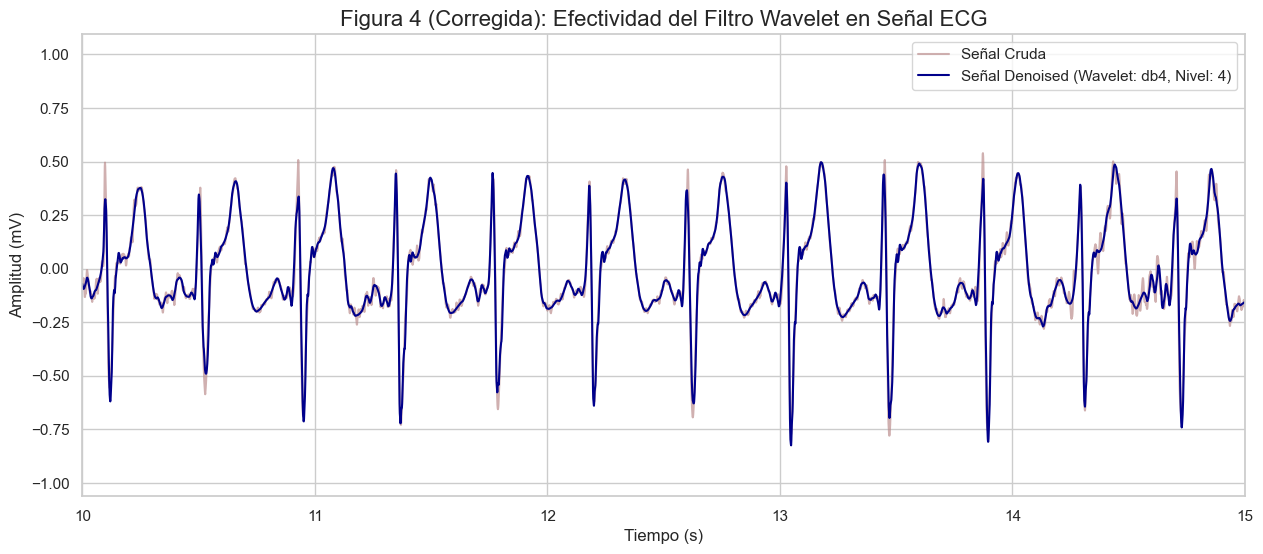

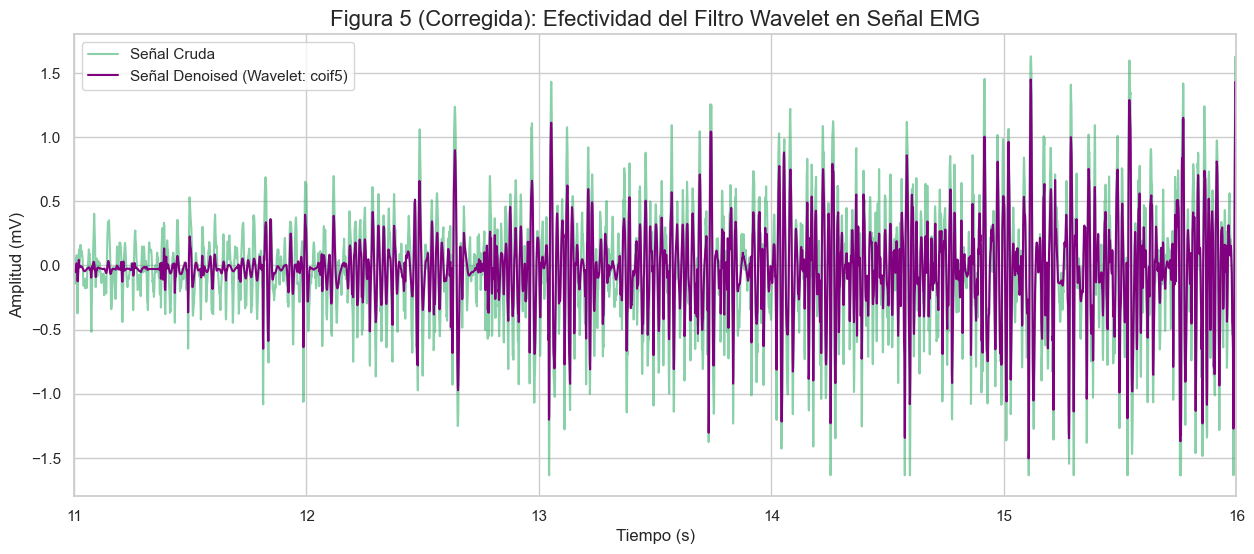

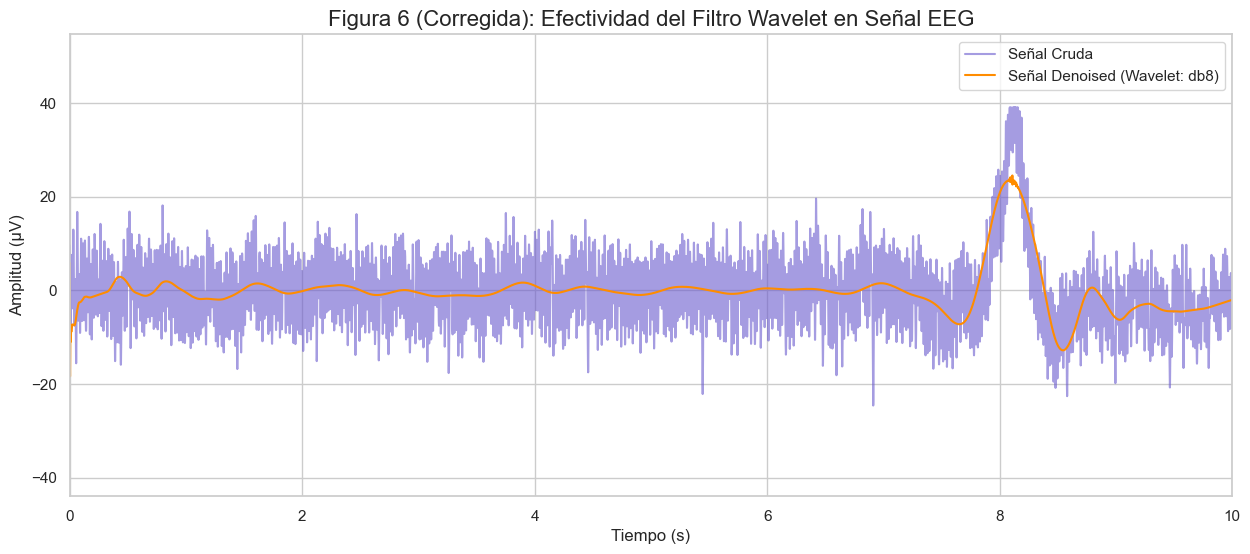


Bibliografía Adicional para la Mejora del Umbral:
[1] Donoho, D. L. (1995). De-noising by soft-thresholding. IEEE Transactions on Information Theory, 41(3), 613-627.
[2] Gaci, S. (2014). Wavelet-based denoising of biomedical signals. In Wavelet Theory and Its Application. IntechOpen. Disponible en: https://www.intechopen.com/chapters/46261



In [18]:
# --- Parámetros de Filtrado CORREGIDOS ---
# Para ECG, reducimos el nivel para no distorsionar el QRS
params_ecg = {'wavelet': 'db4', 'level': 4} 
# Para EMG y EEG, mantenemos el nivel alto pero usaremos la función mejorada
params_emg = {'wavelet': 'coif5', 'level': 8}
params_eeg = {'wavelet': 'db8', 'level': 8}

# --- 1. Procesamiento y Visualización de ECG (con parámetros corregidos) ---
if 'senal_ecg_cruda' in locals() and tiempo_ecg is not None:
    # Usamos la función original, pero con level=4
    senal_ecg_denoised = filtrar_con_wavelet(senal_ecg_cruda, **params_ecg)
    
    plt.figure(figsize=(15, 6))
    plt.plot(tiempo_ecg, senal_ecg_cruda, color='rosybrown', alpha=0.7, label='Señal Cruda')
    plt.plot(tiempo_ecg, senal_ecg_denoised, color='darkblue', linewidth=1.5, label=f'Señal Denoised (Wavelet: {params_ecg["wavelet"]}, Nivel: {params_ecg["level"]})')
    plt.title('Figura 4 (Corregida): Efectividad del Filtro Wavelet en Señal ECG', fontsize=16)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (mV)')
    plt.legend()
    plt.xlim(10, 15)
    plt.show()

# --- 2. Procesamiento y Visualización de EMG (con función mejorada) ---
if 'senal_emg_cruda' in locals() and tiempo_emg is not None:
    # Llamamos a la NUEVA función, más suave
    senal_emg_denoised = filtrar_con_wavelet_mejorado(senal_emg_cruda, **params_emg)
    
    plt.figure(figsize=(15, 6))
    plt.plot(tiempo_emg, senal_emg_cruda, color='mediumseagreen', alpha=0.6, label='Señal Cruda')
    plt.plot(tiempo_emg, senal_emg_denoised, color='purple', linewidth=1.5, label=f'Señal Denoised (Wavelet: {params_emg["wavelet"]})')
    plt.title('Figura 5 (Corregida): Efectividad del Filtro Wavelet en Señal EMG', fontsize=16)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (mV)')
    plt.legend()
    plt.xlim(11, 16)
    plt.show()

# --- 3. Procesamiento y Visualización de EEG (con función mejorada) ---
if 'senal_eeg_cruda' in locals() and tiempo_eeg is not None:
    # Llamamos a la NUEVA función, más suave
    senal_eeg_denoised = filtrar_con_wavelet_mejorado(senal_eeg_cruda, **params_eeg)
    
    plt.figure(figsize=(15, 6))
    plt.plot(tiempo_eeg, senal_eeg_cruda, color='slateblue', alpha=0.6, label='Señal Cruda')
    plt.plot(tiempo_eeg, senal_eeg_denoised, color='darkorange', linewidth=1.5, label=f'Señal Denoised (Wavelet: {params_eeg["wavelet"]})')
    plt.title('Figura 6 (Corregida): Efectividad del Filtro Wavelet en Señal EEG', fontsize=16)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (µV)')
    plt.legend()
    plt.xlim(0, 10)
    plt.show()

# Referencias para la justificación de la mejora
print("""
Bibliografía Adicional para la Mejora del Umbral:
[1] Donoho, D. L. (1995). De-noising by soft-thresholding. IEEE Transactions on Information Theory, 41(3), 613-627.
[2] Gaci, S. (2014). Wavelet-based denoising of biomedical signals. In Wavelet Theory and Its Application. IntechOpen. Disponible en: https://www.intechopen.com/chapters/46261
""")